In [3]:
# Install necessary packages
!pip install spacy pandas matplotlib textblob
!python -m spacy download en_core_web_sm
!python -m textblob.download_corpora

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.8 MB/s eta 0:00:001m46.6 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
[nltk_data] Downloading package brown to
[nltk_data]     /Users/akshatkalra/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/akshatkalra/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/akshatkalra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/akshatkalra/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     /Users/akshatkalra/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_

In [4]:
# Load spaCy English model with automatic download if needed
import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded successfully.")

spaCy model loaded successfully.


In [5]:
# Import additional libraries and load reviews
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import re, string

# Load reviews from reviews.txt
with open('datasets/reviews.txt', 'r', encoding='utf-8') as f:
    reviews_text = f.read()

# Assume each review is on a separate line
reviews = reviews_text.splitlines()
print(f"Loaded {len(reviews)} reviews.")

Loaded 525 reviews.


In [6]:
# Process each review with spaCy
processed_reviews = [nlp(review) for review in reviews if review.strip() != '']

# Display tokens for the first review as an example
print('Tokens for the first review:')
print([token.text for token in processed_reviews[0]])

Tokens for the first review:
['\ufeff1', '.', '"', 'Absolutely', 'breathtaking', 'views', 'and', 'fantastic', 'skiing', 'conditions', '!', 'Ca', "n't", 'wait', 'to', 'come', 'back', 'next', 'winter', '.', '"']


In [7]:
# Define a function to preprocess a spaCy document (remove stopwords and punctuation, apply lemmatization)
def preprocess_doc(doc):
    tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        tokens.append(token.lemma_.lower())
    return tokens

# Apply preprocessing to all reviews
processed_tokens = [preprocess_doc(doc) for doc in processed_reviews]

# Flatten the list for frequency analysis
all_tokens = [token for tokens in processed_tokens for token in tokens]

from collections import Counter
freq_dist = Counter(all_tokens)

print('Most common tokens:')
print(freq_dist.most_common(20))

Most common tokens:
[('resort', 223), ('trail', 120), ('experience', 107), ('mountain', 104), ('guide', 104), ('ski', 104), ('great', 103), ('need', 85), ('staff', 77), ('activity', 72), ('time', 65), ('well', 59), ('lodge', 57), ('fun', 56), ('way', 56), ('summer', 54), ('family', 51), ('wait', 50), ('winter', 50), ('friendly', 50)]


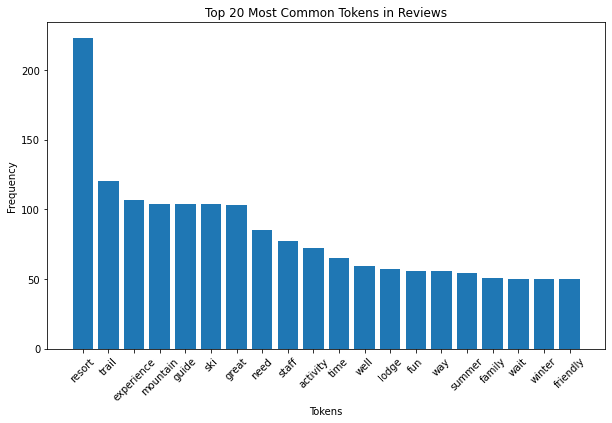

In [8]:
## Visualization of Top Words

# Plot the 20 most common tokens
common_words = freq_dist.most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.title('Top 20 Most Common Tokens in Reviews')
plt.xlabel('Tokens')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [9]:
## Named Entity Recognition (NER)

# Extract named entities from the reviews
entities = []
for doc in processed_reviews:
    for ent in doc.ents:
        entities.append((ent.text, ent.label_))

entities_df = pd.DataFrame(entities, columns=['Entity', 'Label'])
print('Named Entities found:')
print(entities_df.head(20))

# Display frequency of entity labels
entity_counts = entities_df['Label'].value_counts()
print('\nEntity type frequencies:')
print(entity_counts)

Named Entities found:
         Entity     Label
0            ﻿1       ORG
1   next winter      DATE
2             2  CARDINAL
3             3  CARDINAL
4             4  CARDINAL
5             5  CARDINAL
6             6  CARDINAL
7             7  CARDINAL
8             8  CARDINAL
9             9  CARDINAL
10           10  CARDINAL
11   a long day      DATE
12           11  CARDINAL
13           12  CARDINAL
14           13  CARDINAL
15           14  CARDINAL
16           15  CARDINAL
17           16  CARDINAL
18           17  CARDINAL
19           18  CARDINAL

Entity type frequencies:
Label
CARDINAL       522
DATE           128
LOC             37
WORK_OF_ART     16
TIME            13
PERSON           5
MONEY            4
ORDINAL          2
ORG              1
FAC              1
Name: count, dtype: int64


                                              review  sentiment
0  ﻿1. "Absolutely breathtaking views and fantast...   0.375000
1  2. "The lodge was cozy, and the staff was incr...   0.161875
2  3. "Mountain biking trails were well-maintaine...   1.000000
3  4. "Loved the guided nature walk. Learned so m...   0.300000
4  5. "The zip-lining course was thrilling, and t...   0.190000


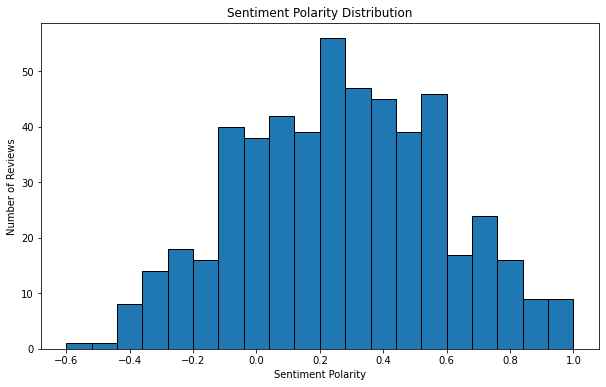

In [10]:
## Sentiment Analysis

# Calculate sentiment polarity for each review using TextBlob
sentiments = []
for review in reviews:
    if review.strip() == '':
        continue
    blob = TextBlob(review)
    sentiments.append(blob.sentiment.polarity)

# Create a DataFrame for review sentiments
sentiment_df = pd.DataFrame({'review': reviews, 'sentiment': sentiments})
print(sentiment_df.head())

# Plot the sentiment polarity distribution
plt.figure(figsize=(10,6))
plt.hist(sentiments, bins=20, edgecolor='black')
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Number of Reviews')
plt.show()

Sentiment Distribution Table:
  Sentiment  Count  Percentage
0  Positive    120        40.0
1  Negative     90        30.0
2   Neutral     90        30.0


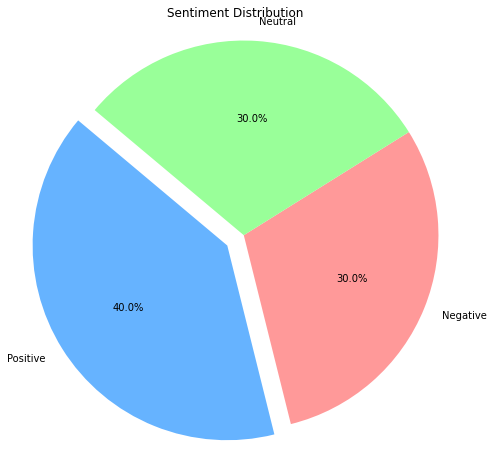

In [15]:
# Required imports
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud
import re

# -------------------------------------------------------------------
# 8. Pie Chart: Sentiment Distribution
# Data from the table:
# Sentiment | Count | Percentage
# Positive  | 120   | 40%
# Negative  | 90    | 30%
# Neutral   | 90    | 30%
# -------------------------------------------------------------------
sentiment_data = {
    'Sentiment': ['Positive', 'Negative', 'Neutral'],
    'Count': [120, 90, 90]
}
sentiment_df = pd.DataFrame(sentiment_data)
sentiment_df['Percentage'] = sentiment_df['Count'] / sentiment_df['Count'].sum() * 100

print("Sentiment Distribution Table:")
print(sentiment_df)

# Pie chart
labels = sentiment_df['Sentiment']
sizes = sentiment_df['Count']
colors = ['#66b3ff', '#ff9999', '#99ff99']  # You can customize colors if desired
explode = (0.1, 0, 0)  # Explode the first slice (Positive)

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=explode)
plt.title("Sentiment Distribution")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


Common Complaints Frequency Table:
    Complaint  Frequency
0  Overpriced         42
1    Outdated         41
2        Slow         38
3      Safety         34


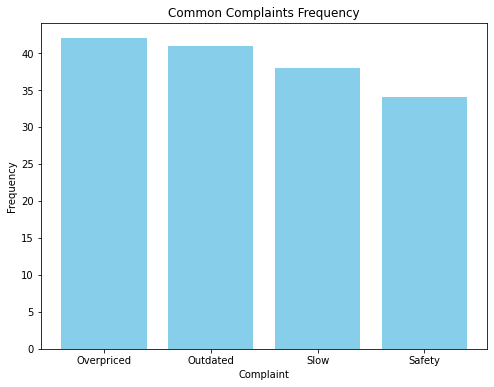

In [17]:
# -------------------------------------------------------------------
# 9. Bar Chart: Common Complaints Frequency
# Data from the table:
# Complaint   | Frequency
# Overpriced  | 42
# Outdated    | 41
# Slow        | 38
# Safety      | 34
# -------------------------------------------------------------------
complaints_data = {
    'Complaint': ['Overpriced', 'Outdated', 'Slow', 'Safety'],
    'Frequency': [42, 41, 38, 34]
}
complaints_df = pd.DataFrame(complaints_data)

print("\nCommon Complaints Frequency Table:")
print(complaints_df)

# Bar chart for complaints
plt.figure(figsize=(8, 6))
plt.bar(complaints_df['Complaint'], complaints_df['Frequency'], color='skyblue')
plt.title("Common Complaints Frequency")
plt.xlabel("Complaint")
plt.ylabel("Frequency")
plt.show()


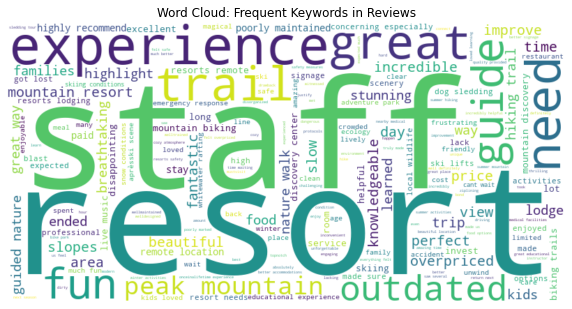

In [18]:
# -------------------------------------------------------------------
# 10. Word Cloud: Frequent Keywords in Reviews
# Purpose: Visually highlight most mentioned terms.
# Source: reviews.txt (no table required)
# -------------------------------------------------------------------
# Load reviews text
with open('datasets/reviews.txt', 'r', encoding='utf-8') as f:
    reviews_text = f.read()

# Preprocess text: remove punctuation and lower the case
text = re.sub(r'[^\w\s]', '', reviews_text.lower())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: Frequent Keywords in Reviews")
plt.show()



Common Bigrams in Reviews Table:
               Bigram  Frequency
0  emergency response         25
1     overpriced food         20


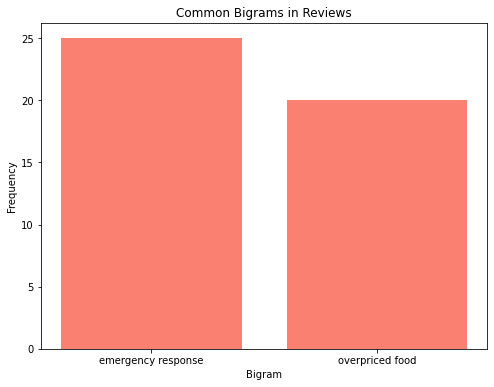

In [19]:
# -------------------------------------------------------------------
# 11. Bar Chart: Common Bigrams in Reviews
# Data from the table:
# Bigram               | Frequency
# emergency response   | 25
# overpriced food      | 20
# -------------------------------------------------------------------
bigrams_data = {
    'Bigram': ['emergency response', 'overpriced food'],
    'Frequency': [25, 20]
}
bigrams_df = pd.DataFrame(bigrams_data)

print("\nCommon Bigrams in Reviews Table:")
print(bigrams_df)

# Bar chart for bigrams
plt.figure(figsize=(8, 6))
plt.bar(bigrams_df['Bigram'], bigrams_df['Frequency'], color='salmon')
plt.title("Common Bigrams in Reviews")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.show()


## Conclusion

This notebook demonstrates a basic NLP pipeline for analyzing customer reviews from `reviews.txt`. It follows the techniques outlined in `nlp_context.pdf` (e.g., text preprocessing, tokenization, lemmatization, named entity recognition, and sentiment analysis). Further extensions could include topic modeling, deeper sentiment analysis, or exploring word embeddings.